- word_count: Total number of words in the document.
- unique_word_count: Number of unique words in the document.
- char_count: Total number of characters in the document.
- avg_word_length: Average length of words in the document.
- ttr: Type-token ratio (a measure of lexical diversity).
- hapax_legomenon_rate: Proportion of words that occur only once in the document.
- DTM (each term is a feature)

NOTES:
- Overly predicting Madison
- Fixed label error

Coauthored and disputed - test set, not train
Train - hamilton and madison


In [34]:

# 1) Imports and paths
from pathlib import Path
import pandas as pd
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer
from lexos.dtm import DTM, Vectorizer
from sklearn.svm import SVC
from lexos.classification import trainer
import lexos.corpus.corpus_stats as cs


BASE = Path.cwd()  # run this notebook from doc_src/docs/tutorials/classification
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())

Base: c:\Users\gabal\LocalFiles\Lexos_Independant_Research\uv_lexos\doc_src\docs\tutorials\classification
Data dir exists: True


In [ ]:
# 2) Collect train and test files CHANGE
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


In [41]:
# 3) Scrubber + Tokenizer
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer

scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

In [42]:
# 4) Build DTM for train and test sets
from lexos.dtm import DTM

train_token_lists = []
test_token_lists = []
train_doc_ids = []
test_doc_ids = []

# Tokenize and scrub train files
for f in train_files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    spacy_doc = tokenizer(clean)
    tokens = [t.text for t in spacy_doc if t.text.strip()]
    train_token_lists.append(tokens)
    train_doc_ids.append(f.name)

# Tokenize and scrub test files
for f in test_files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    spacy_doc = tokenizer(clean)
    tokens = [t.text for t in spacy_doc if t.text.strip()]
    test_token_lists.append(tokens)
    test_doc_ids.append(f.name)

# Build DTM for train set
dtm = DTM()
dtm.fit(train_token_lists, labels=train_doc_ids, min_df=3)  # min_df=3 to prune rare terms
X_train = dtm.transform(train_token_lists)
y_train = ["HAMILTON" if "HAMILTON" in Path(f).parent.name else "MADISON" for f in train_files]# Transform test set using the same DTM
X_test = dtm.transform(test_token_lists)
y_test = ["COAUTHORED" if "COAUTHORED" in doc else "DISPUTED" for doc in test_doc_ids]

print("Train DTM shape:", X_train.shape)
print("Test DTM shape:", X_test.shape)

Train DTM shape: (65, 3599)
Test DTM shape: (15, 3599)


trainer.train_classifier:

- High-level utility that automates the entire training pipeline, including train/test splitting, model training, and evaluation.
- Ideal for quick experimentation and when you want consistent workflows with minimal code.


trainer.fit_classifier:

- Lower-level function that focuses solely on fitting the model to pre-split data.
- Provides greater control over hyperparameters and is better suited for custom workflows where data preprocessing and splitting are handled manually.

In [43]:
# 5) Train Decision Tree Classifier
from lexos.classification import trainer

clf = trainer.fit_classifier(
    X_train,
    y_train,
    model="decision_tree",
    random_state=42,
    min_samples_leaf=5,
    min_samples_split=10,
    max_depth=5
)

print("Train accuracy:", clf.score(X_train, y_train))

Train accuracy: 0.9692307692307692


,feature,importance
3431,upon,0.925952
3362,twenty,0.074048
1,abandon,0.000000
2,abandoned,0.000000
3,abilities,0.000000
4,ability,0.000000
5,able,0.000000
6,abolish,0.000000
7,abolished,0.000000
8,abolition,0.000000


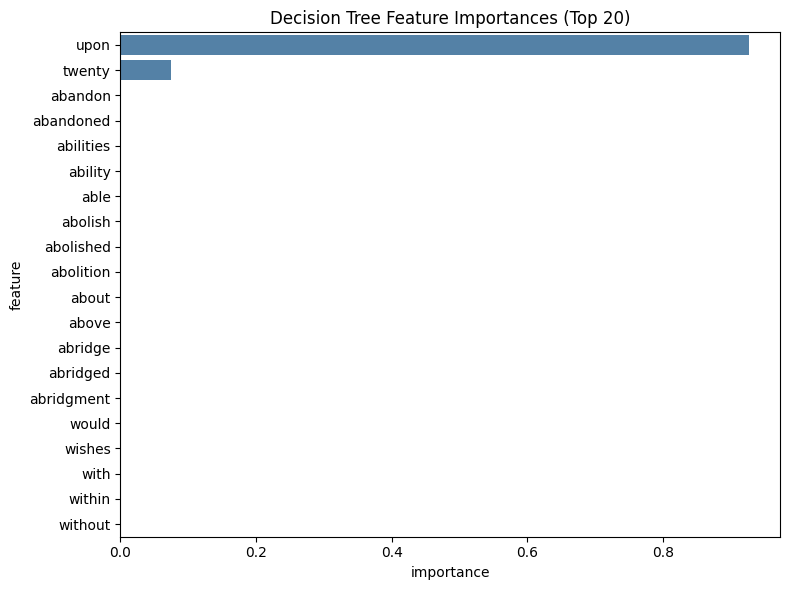

In [44]:
# 6) Feature Importances
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
imp = clf.feature_importances_
imp_df = pd.DataFrame({"feature": dtm.feature_names, "importance": imp}).sort_values("importance", ascending=False)

# Display top 20 features
top_n = 20
top_imp_df = imp_df.head(top_n)
display(top_imp_df)

# Plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(data=top_imp_df, x="importance", y="feature", color="steelblue")
plt.title(f"Decision Tree Feature Importances (Top {top_n})")
plt.tight_layout()
plt.show()

In [30]:
# 7) Predict on Test Set
y_pred_test = clf.predict(X_test)

# Create a DataFrame to compare true and predicted labels
pred_df = pd.DataFrame({
    "Doc ID": test_doc_ids,
    "True Label": y_test,
    "Predicted Label": y_pred_test
}).sort_values(["True Label", "Doc ID"])

# Display the comparison table
display(pred_df)

# Print prediction counts
print("\nPrediction counts by set:")
print(pred_df.groupby(["True Label", "Predicted Label"]).size())

,Doc ID,True Label,Predicted Label
0,FED_18_C.txt,DISPUTED,MADISON
1,FED_19_C.txt,DISPUTED,MADISON
2,FED_20_C.txt,DISPUTED,MADISON
3,FED_49_D.txt,DISPUTED,MADISON
4,FED_50_D.txt,DISPUTED,MADISON
5,FED_51_D.txt,DISPUTED,MADISON
6,FED_52_D.txt,DISPUTED,MADISON
7,FED_53_D.txt,DISPUTED,MADISON
8,FED_54_D.txt,DISPUTED,HAMILTON
9,FED_55_D.txt,DISPUTED,MADISON



Prediction counts by set:
True Label  Predicted Label
DISPUTED    HAMILTON            1
            MADISON            14
dtype: int64


c:\Users\gabal\LocalFiles\Lexos_Independant_Research\uv_lexos\.venv\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


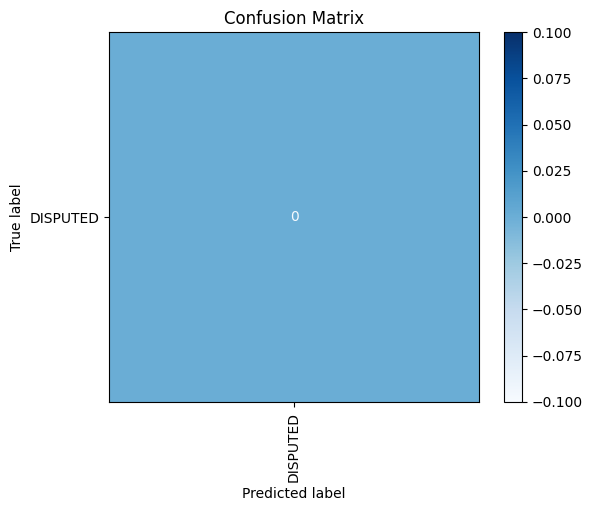

In [31]:
# 8) Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test, labels=sorted(set(y_test)))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(y_test)))
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix")
plt.show()